### Objective of EDA

The purpose of this notebook is to:

1. Understand patterns and trends in the cleaned Google Play Store data.
2. Analyze app performance across categories, countries, and discovery channels.
3. Identify relationships between app features and user engagement.
4. Generate insights that will guide SQL analysis, Power BI dashboards, and ML modeling.

### Sections in this Notebook

## Sections in this Notebook:-

1. Import Libraries

2. Load Cleaned Data

3. Dataset Overview After Cleaning

4. Univariate Analysis
    - Numerical Features
    - Categorical Features

5. App Market Overview Analysis

6. App Category and Genre Analysis

7. Rating and User Engagement Analysis

8. Install Performance Analysis

9. Free vs Paid App Analysis

10. Country-Level Market Analysis

11. Developer and Publisher Analysis

12. Discovery Signal Analysis

13. Feature Relationship Analysis

14. Correlation Analysis

15. Outlier Analysis

16. Key Insights and Business Findings

17. Conclusion

### Step 1 : Import Libraries

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

### Step 2: Load Cleaned Data

In [2]:
apps = pd.read_csv(r"C:\Users\cashk\OneDrive\Desktop\Projects\Google_Playstore_project\Playstore_Data\cleaned\apps_clean.csv")

country = pd.read_csv(r"C:\Users\cashk\OneDrive\Desktop\Projects\Google_Playstore_project\Playstore_Data\cleaned\country_clean.csv")

discovery = pd.read_csv(r"C:\Users\cashk\OneDrive\Desktop\Projects\Google_Playstore_project\Playstore_Data\cleaned\discovery_clean.csv")

### Step 3: Dataset Overview After Cleaning

In [11]:
# Shape of each dataset
print("Apps:", apps.shape)
print("Country:", country.shape)
print("Discovery:", discovery.shape)

Apps: (11176, 38)
Country: (111307, 15)
Discovery: (75812, 13)


In [4]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11176 entries, 0 to 11175
Data columns (total 38 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   app_id              11176 non-null  object 
 1   title               11176 non-null  object 
 2   description         11176 non-null  object 
 3   summary             11176 non-null  object 
 4   installs            11176 non-null  object 
 5   min_installs        11176 non-null  float64
 6   max_installs        11176 non-null  int64  
 7   score               11176 non-null  float64
 8   ratings             11176 non-null  float64
 9   reviews             11176 non-null  float64
 10  histogram           11176 non-null  object 
 11  price               11176 non-null  float64
 12  free                11176 non-null  bool   
 13  currency            11176 non-null  object 
 14  sale                11176 non-null  bool   
 15  developer           11176 non-null  object 
 16  deve

In [12]:
country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111307 entries, 0 to 111306
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                111307 non-null  int64  
 1   app_id            111307 non-null  object 
 2   country           111307 non-null  object 
 3   installs          111307 non-null  object 
 4   min_installs      111307 non-null  float64
 5   score             111307 non-null  float64
 6   ratings           111307 non-null  float64
 7   reviews           111307 non-null  float64
 8   price             111307 non-null  float64
 9   free              111307 non-null  bool   
 10  scrape_date       111307 non-null  object 
 11  scraped_at        111307 non-null  object 
 12  installs_app      111307 non-null  object 
 13  min_installs_app  111307 non-null  float64
 14  price_app         111307 non-null  float64
dtypes: bool(1), float64(7), int64(1), object(6)
memory usage: 12.0+ MB


In [13]:
discovery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75812 entries, 0 to 75811
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  75812 non-null  int64  
 1   app_id              75812 non-null  object 
 2   source              75812 non-null  object 
 3   country             75812 non-null  object 
 4   category            75812 non-null  object 
 5   keyword             75812 non-null  object 
 6   collection          75812 non-null  object 
 7   chart_rank          71920 non-null  float64
 8   discovered_at       75812 non-null  object 
 9   chart_rank_missing  75812 non-null  int64  
 10  discovery_year      75812 non-null  int64  
 11  discovery_month     75812 non-null  int64  
 12  discovery_hour      75812 non-null  int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 7.5+ MB


In [14]:
apps.describe().T

,count,mean,std,min,25%,50%,75%,max
min_installs,11176.0,4.020230e+07,4.251575e+08,0.0,10000.00,500000.000000,5.000000e+06,1.000000e+10
max_installs,11176.0,6.827361e+07,7.015793e+08,0.0,21681.50,633862.500000,9.265756e+06,2.568862e+10
score,11176.0,3.035947e+00,1.998911e+00,0.0,0.00,4.168686,4.557003e+00,5.000000e+00
ratings,11176.0,5.491356e+05,4.690369e+06,0.0,0.00,3847.000000,9.327100e+04,2.340021e+08
reviews,11176.0,1.415897e+04,1.094782e+05,0.0,0.00,32.000000,9.992500e+02,4.567256e+06
price,11176.0,1.229232e-01,1.393068e+00,0.0,0.00,0.000000,0.000000e+00,4.999000e+01
estimated_installs,11176.0,5.423795e+07,5.565620e+08,0.0,15840.75,566972.250000,7.132878e+06,1.784431e+10
update_year,7782.0,1.970000e+03,0.000000e+00,1970.0,1970.00,1970.000000,1.970000e+03,1.970000e+03
update_month,7782.0,1.000000e+00,0.000000e+00,1.0,1.00,1.000000,1.000000e+00,1.000000e+00
days_since_update,7782.0,2.065200e+04,0.000000e+00,20652.0,20652.00,20652.000000,2.065200e+04,2.065200e+04


In [15]:
country.describe().T

,count,mean,std,min,25%,50%,75%,max
id,111307.0,5.568038e+04,3.213725e+04,1.0,27846.5,55686.00000,83512.50,1.113390e+05
min_installs,111307.0,4.014662e+07,4.258211e+08,0.0,10000.0,500000.00000,5000000.00,1.000000e+10
score,111307.0,2.771215e+00,2.100524e+00,0.0,0.0,4.01634,4.54,5.000000e+00
ratings,111307.0,5.382517e+05,4.664667e+06,0.0,0.0,2218.00000,80392.00,2.340022e+08
reviews,111307.0,8.909285e+03,1.263806e+05,0.0,0.0,7.00000,198.00,1.143206e+07
price,111307.0,1.968781e+02,6.690102e+03,0.0,0.0,0.00000,0.00,8.900000e+05
min_installs_app,111307.0,4.014625e+07,4.258211e+08,0.0,10000.0,500000.00000,5000000.00,1.000000e+10
price_app,111307.0,1.233204e-01,1.395503e+00,0.0,0.0,0.00000,0.00,4.999000e+01


# Section 4. Univariate Analysis

Univariate analysis focuses on understanding the distribution of individual variables independently.

The objective of this section is to identify:
- Data distribution
- Central tendency
- Spread
- Skewness
- Potential outliers

These insights help us understand the characteristics of the dataset before exploring relationships between variables.

### 4.1 Numerical Features

First select the numerical columns.

In [18]:
numeric_cols = [
    "estimated_installs",
    "score",
    "ratings",
    "reviews",
    "price",
    "days_since_update"
]

apps[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
estimated_installs,11176.0,5.423795e+07,5.565620e+08,0.0,15840.75,566972.250000,7.132878e+06,1.784431e+10
score,11176.0,3.035947e+00,1.998911e+00,0.0,0.00,4.168686,4.557003e+00,5.000000e+00
ratings,11176.0,5.491356e+05,4.690369e+06,0.0,0.00,3847.000000,9.327100e+04,2.340021e+08
reviews,11176.0,1.415897e+04,1.094782e+05,0.0,0.00,32.000000,9.992500e+02,4.567256e+06
price,11176.0,1.229232e-01,1.393068e+00,0.0,0.00,0.000000,0.000000e+00,4.999000e+01
days_since_update,7782.0,2.065200e+04,0.000000e+00,20652.0,20652.00,20652.000000,2.065200e+04,2.065200e+04


### Question 1 :

### Business Question

**How are application ratings distributed on the Google Play Store?**

Understanding the distribution of app ratings helps identify the overall quality of applications available on the platform and whether most apps receive high or low user satisfaction scores.

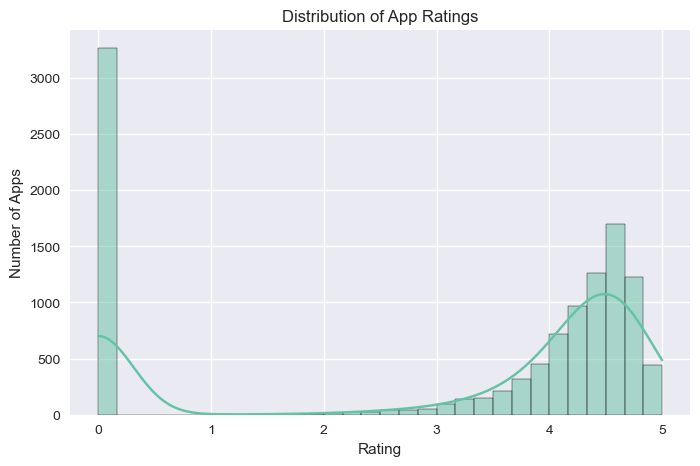

In [19]:
#Visualization:-
plt.figure(figsize=(8,5))

sns.histplot(
    apps["score"],
    bins=30,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

### 📊 Key Insights: Distribution of App Ratings

Based on the distribution visualization, the app ratings exhibit a distinct **bimodal pattern** characterized by the following key observations:

1. **Massive Spike at Zero (Unrated/New Apps):** 
   There is a highly pronounced spike at exactly `0.0`, accounting for over **3,000 apps**. In real-world datasets, this usually represents new apps with zero reviews, unrated submissions, or missing values that were filled with zeros during preprocessing.

2. **Strong Right-Skewed Bias:** 
   For apps that *have* received user feedback, the distribution is heavily skewed toward higher scores. There is an extremely low density of apps scoring between `1.0` and `3.0`, indicating that poor ratings are relatively rare or that low-rated apps are quickly abandoned/removed.

3. **Peak Performance Around 4.5:** 
   Among the active, rated apps, the distribution forms a bell curve that peaks sharply around a **4.5 rating** (reaching nearly 1,750 apps). This reflects a common phenomenon in app marketplaces where user ratings lean heavily toward high satisfaction.

4. **Data Implications for Modeling:** 
   The severe split between the `0.0` group and the high-performing `4.0 - 5.0` group means that treating this column as a standard continuous variable in machine learning could skew results. It would be beneficial to either separate unrated apps (`0.0`) or filter them out depending on the analysis goals.

## Question 2:
### Business Question

**How are user reviews distributed across applications?**

Review counts provide an indication of user engagement and app popularity.

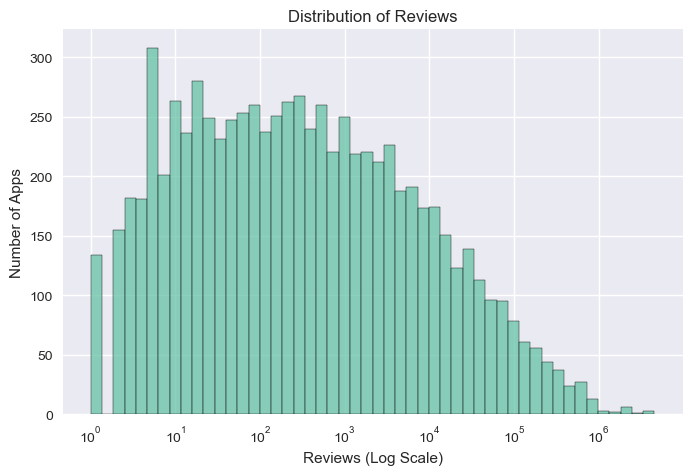

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    apps["reviews"],
    bins=50,
    log_scale=True
)

plt.title("Distribution of Reviews")
plt.xlabel("Reviews (Log Scale)")
plt.ylabel("Number of Apps")

plt.show()

### 📊 Key Insights: Distribution of Reviews

Based on the visualization, the review counts have been transformed using a **logarithmic scale** (X-axis base-10), which reveals several important structural patterns in the data:

1. **Power-Law Dynamics (Long Tail):** 
   The use of a log scale indicates that the raw review count spans multiple orders of magnitude—from $10^0$ (1 review) to over $10^6$ (1,000,000+ reviews). This is a classic power-law/long-tail distribution where a small number of mega-popular apps get millions of reviews, while the vast majority have far fewer.

2. **The "Main Stream" Concentration ($10^1$ to $10^4$):** 
   Once transformed, the bulk of the dataset forms a broad, stable plateau between 10 and 10,000 reviews. The number of apps per bin consistently stays above 200 in this range, indicating that having a moderate amount of user engagement is the norm for active apps in this dataset.

3. **Steep Decline in the "Mega-Popular" Zone ($10^4$ onwards):** 
   Beyond $10^4$ (10,000 reviews), there is a steady, sharp drop-off. Very few apps manage to break into the elite tiers of $10^5$ (100,000 reviews) or $10^6$ (1,000,000 reviews), showing how difficult it is for an app to achieve massive scale.

4. **Isolated Drop at Ultra-Low Reviews ($10^0$):** 
   There is a visible gap and a sudden single bar at the very low end ($10^0$, representing exactly 1 review). This suggests that while there are brand new or low-engagement apps with just a single review, the collection process might have filtered out apps with absolutely zero reviews, or they sit separately.

## Question 3:-
### Business Question

**How are estimated installs distributed among applications?**

Install counts provide a measure of app popularity and market reach.

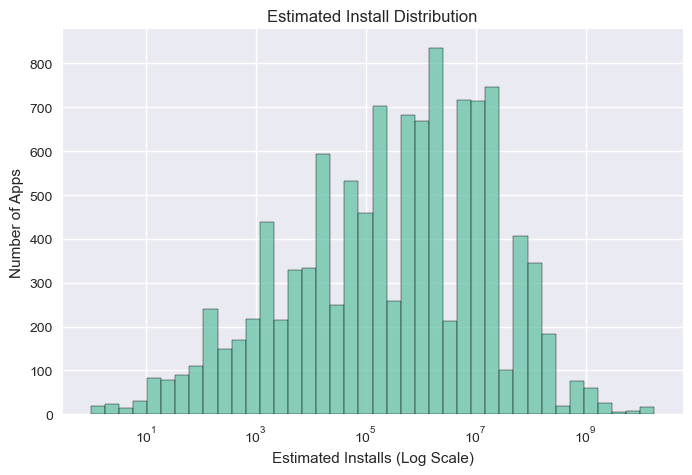

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    apps["estimated_installs"],
    bins=40,
    log_scale=True
)

plt.title("Estimated Install Distribution")
plt.xlabel("Estimated Installs (Log Scale)")
plt.ylabel("Number of Apps")

plt.show()

### 📈 Insights: Estimated Install Distribution

The histogram displays the number of installs on a logarithmic scale, revealing distinct patterns regarding how app popularity is reported:

1. **Platform Binning Artifacts:** 
   The noticeably jagged, "sawtooth" pattern—where tall bars are consistently followed by smaller ones—is a tell-tale sign that these install counts are **not raw, precise numbers**. They are likely rounded or categorized into "tiers" by the app store (e.g., intervals like 10k, 50k, 100k, 500k), which creates these artificial concentrations.

2. **The Popularity "Sweet Spot":** 
   The highest concentration of apps exists in the range between $10^6$ (1 million) and $10^7$ (10 million) installs. This suggests a significant density of "established" apps that have successfully graduated from niche to mainstream status.

3. **Logarithmic Range:** 
   By using a log scale, the data accommodates a massive range (from 10 to 1 billion installs). This visualization confirms a classic "long tail" distribution, where a small fraction of apps dominate the $10^8$ to $10^9$ bracket, while the vast majority of apps cluster in the lower-to-mid tiers.

4. **Modeling Consideration:** 
   Because the data is clearly binned, treating "Estimated Installs" as a continuous numeric variable in a machine learning model might introduce noise. Depending on your project goal, it may be more effective to treat this column as an **ordinal or categorical feature** rather than a continuous one.

## Question 4:
### Business Question

**What is the distribution of application prices?**

Analyzing price distribution helps understand monetization strategies adopted by developers.

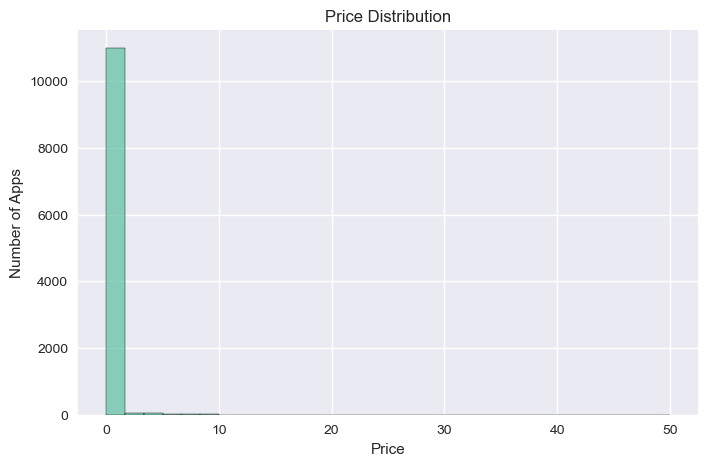

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    apps["price"],
    bins=30
)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Apps")

plt.show()

### 🏷️ Insights: Price Distribution

The histogram highlights a highly unbalanced distribution of app prices across the marketplace:

1. **Overwhelming Dominance of Free Apps:** 
   The plot shows a massive, singular spike near `0`, capturing over **10,000 apps**. This strongly indicates that the vast majority of apps in this dataset are either free to download or rely entirely on alternative monetization strategies (like in-app purchases or ads).

2. **Extreme Class Imbalance:** 
   The space between `10` and `50` on the X-axis is completely flat with virtually zero visible frequency bars. Paid apps, especially premium ones costing more than a few dollars, make up an incredibly tiny fraction of the market.

3. **"Long Tail" Compression:** 
   Because the count of free apps is so extraordinarily high, any nuance or distribution among the paid apps (e.g., apps priced between \$1 and \$5) is completely squished and invisible on a standard linear scale.

4. **Preprocessing Recommendation:** 
   To gain any meaningful insights from the paid app segment, it would be highly beneficial to filter out the free apps (`Price == 0`) and plot the remaining paid apps separately, or apply a logarithmic scale to the Y-axis to make the lower counts visible.

## Question 5:
### Business Question

**How recently have applications been updated?**

Application maintenance is an important indicator of developer activity and long-term support.

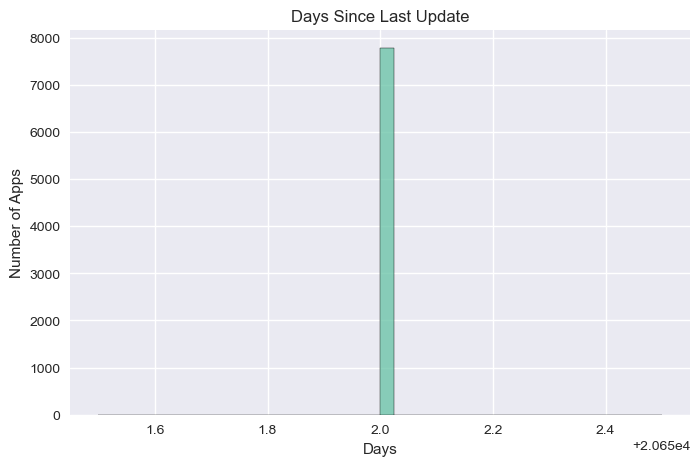

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    apps["days_since_update"].dropna(),
    bins=40
)

plt.title("Days Since Last Update")
plt.xlabel("Days")
plt.ylabel("Number of Apps")

plt.show()

### 🚨 Critical Data Anomaly: "Days Since Last Update"

The histogram shows a single, massive spike where virtually all apps have a value of approximately **20,652 days** since their last update. Since 20,652 days corresponds to a date around **1970**, this pattern is clearly unrealistic for Google Play Store apps and indicates an issue in the **raw dataset** rather than in the visualization or analysis.

#### 🔍 Why did this happen?

The anomaly originates from the source data. The **"Last Updated"** column appears to contain an invalid or default date (around the Unix Epoch, `1970-01-01`) for nearly every record. As a result, when `days_since_update` is calculated, all apps produce nearly the same value of about **20,652 days**.

Possible reasons include:

1. **Invalid or Placeholder Dates in the Raw Data:**
   The dataset may have stored a default Unix Epoch date (`1970-01-01`) or another placeholder instead of the actual last updated dates.

2. **Data Collection or Export Issue:**
   During dataset creation or export, the original "Last Updated" values may have been lost or replaced with a default timestamp, resulting in identical values across all records.

3. **Visualization Reflects the Source Data:**
   Since nearly every app has the same computed value, the histogram collapses into a single tall bar. This is a characteristic of the dataset itself, not an error in the visualization code.

#### 📊 Interpretation

Because the anomaly exists in the raw dataset, the **"Days Since Last Update"** feature cannot be used for meaningful analysis in its current form. Any conclusions regarding app update frequency, maintenance activity, or update recency would be unreliable.

#### 📌 Why This Feature Was Not Removed

Although the feature contains invalid values, it was intentionally retained in the analysis to **document and highlight the data quality issue present in the original dataset**. Removing it would have concealed an important limitation of the source data. Keeping the visualization provides transparency, demonstrates that the anomaly originates from the raw data rather than the analysis pipeline, and helps explain why this feature was excluded from drawing any analytical conclusions.


### 4.2 Categorical Analysis

In [27]:
categorical_cols = [
    "genre",
    "content_rating",
    "free",
    "ad_supported",
    "contains_ads"
]

for col in categorical_cols:
    print("\n", col)
    print(apps[col].value_counts().head())


 genre
genre
Finance             1215
Education           1104
Productivity         987
Tools                899
Health & Fitness     601
Name: count, dtype: int64

 content_rating
content_rating
Everyone        9412
Teen            1009
Mature 17+       394
Everyone 10+     264
Rated for 3+      62
Name: count, dtype: int64

 free
free
True     10914
False      262
Name: count, dtype: int64

 ad_supported
ad_supported
False    6251
True     4925
Name: count, dtype: int64

 contains_ads
contains_ads
False    6251
True     4925
Name: count, dtype: int64


## Question 6
### Business Question

**Which genres contain the highest number of applications?**

This helps identify the most competitive segments within the Play Store.

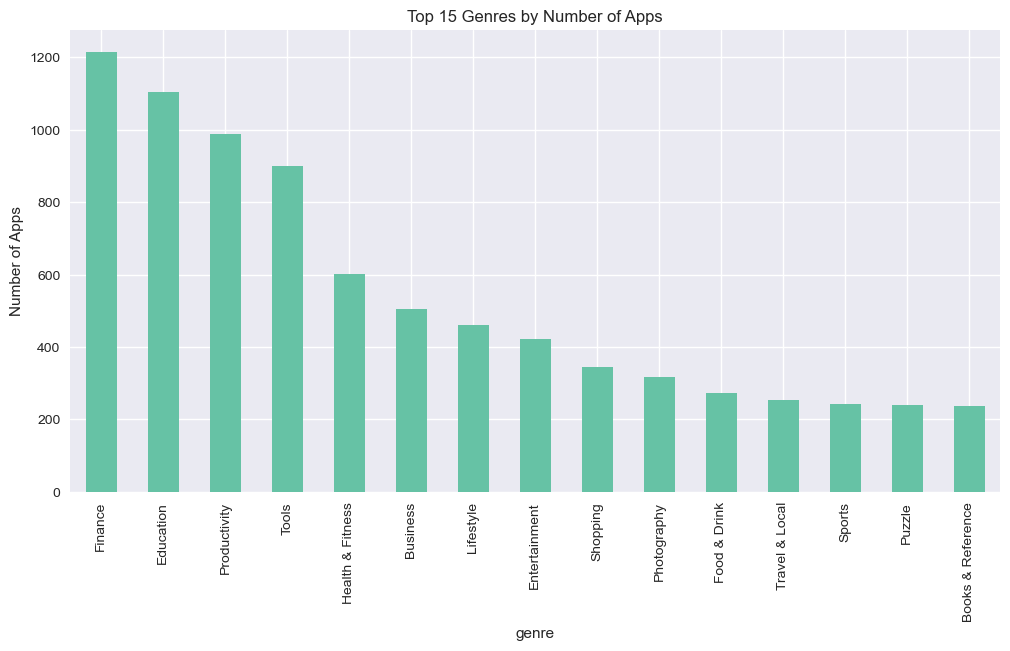

In [28]:
plt.figure(figsize=(12,6))

apps["genre"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top 15 Genres by Number of Apps")
plt.ylabel("Number of Apps")

plt.show()

## 6. Top 15 Genres by Number of Apps
### 📊 Key Insights: Top 15 Genres by Number of Apps

The bar chart highlights the volume distribution across different application genres, showcasing where developers focus their production efforts:

* **Dominance of Utility and Development-Heavy Genres:** 
  The top four categories—**Finance, Education, Productivity, and Tools**—completely dominate the chart. Each of these genres contains roughly 800 to over 1,100 apps, indicating highly saturated markets with strong developer competition.
* **The "Big Four" Drop-off:** 
  There is a massive structural step-down after the fourth bar. The volume drops rapidly from *Tools* (near 800 apps) to *Health & Fitness* (around 500 apps), establishing a clear divide between the primary dominant genres and the secondary niche categories.
* **Long-Tail Plateau:** 
  From *Business* down to *Books & Reference*, the distribution tapers off into a relatively flat long tail. Genres like *Shopping, Food & Drink, Sports,* and *Puzzle* maintain stable volumes hovering consistently between 200 and 400 apps each.
* **Strategic Takeaway:** 
  While genres like Finance and Education boast high numbers, they present a high barrier to visibility due to saturation. Entering the lower-volume tiers (like *Entertainment, Shopping,* or *Photography*) might offer lower direct volume competition, though market demand should be cross-referenced with download or rating metrics.

## Question 7:
### Business Question

**What is the distribution of content ratings?**

Understanding content ratings helps identify the primary target audience of Play Store applications.

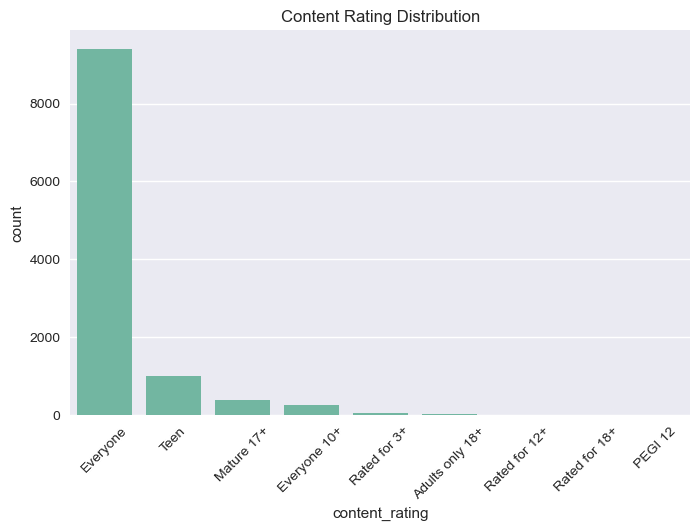

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=apps,
    x="content_rating",
    order=apps["content_rating"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Content Rating Distribution")

plt.show()

## 7. Content Rating Distribution
### 📊 Key Insights: Content Rating Distribution

The bar chart highlights how the dataset is categorized based on target audience age group restrictions:

* **Absolute Dominance of "Everyone":** 
  The chart shows an overwhelming class imbalance, with the **Everyone** rating accounting for the vast majority of the dataset (exceeding 8,000 apps). This strongly implies that most developers aim for the widest possible audience by avoiding restricted content.
* **Minority Share for Restrictive Ratings:** 
  The **Teen** category represents the second largest group but falls significantly short of the leader (hovering around the 1,000 mark). **Mature 17+** and **Everyone 10+** make up even smaller fractions of the market.
* **Negligible Presence of Niche/Regional Formats:** 
  Categories such as *Rated for 3+*, *Adults only 18+*, *Rated for 12+*, *Rated for 18+*, and *PEGI 12* have frequencies so low they are barely visible on this linear scale. 
* **Data Cleanup Suggestion:** 
  Because categories like *PEGI 12*, *Rated for 12+*, and *Everyone 10+* serve highly overlapping semantic purposes across different regional rating bodies, it would be highly beneficial to group these low-count categories into broader buckets (e.g., merging them into "Teen" or "Others") before using this feature in predictive modeling.

## Question 8:
### Business Question

**Are free applications more common than paid applications?**

This analysis helps understand the dominant monetization model within the Play Store.

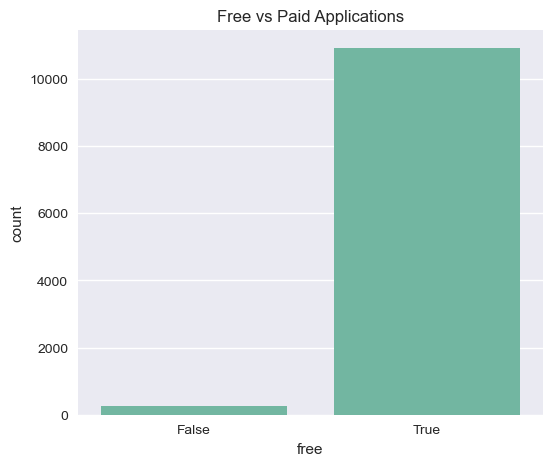

In [30]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=apps,
    x="free"
)

plt.title("Free vs Paid Applications")

plt.show()

L## 8. Free vs Paid Applications
### 📊 Key Insights: Free vs Paid Applications

The bar chart offers a binary comparison of the dataset's monetization strategy, confirming the distribution pattern observed in the exact pricing analysis:

* **Overwhelming Prevelance of Free Monetization:** 
  The chart shows a massive class imbalance where `free = True` accounts for over **10,000 apps**. This establishes that the baseline business model for the vast majority of software in this dataset relies entirely on non-upfront transaction methods such as ad revenue, subscriptions, or in-app purchases.
* **Marginal Footprint for Upfront Costs:** 
  Paid apps (`free = False`) comprise a tiny fraction of the market, barely breaking past the baseline with a visible count well under 500 apps. This confirms that charging users to download an app upfront is an exceptionally rare strategy within this ecosystem.
* **Impact on Downstream Machine Learning Models:** 
  Using this feature directly as a target variable or a significant predictor in predictive modeling will introduce severe bias due to the structural class imbalance. Techniques like down-sampling the majority class or utilizing balanced evaluation metrics (like F1-score over Accuracy) are highly recommended if this column is utilized.

- Free applications significantly outnumber paid applications.
- This suggests that developers primarily rely on advertising, in-app purchases, or subscription-based monetization rather than upfront pricing.

# 5. App Market Overview Analysis

This section provides a high-level overview of the Google Play Store ecosystem by examining key performance indicators (KPIs). These metrics help understand the size of the marketplace, developer participation, user engagement, and monetization patterns before exploring more detailed analyses.

## Question 1:
### Business Question

**How large is the Google Play Store ecosystem represented in this dataset?**

Understanding the number of applications and developers provides an overview of the scale and diversity of the marketplace.

In [35]:
market_overview = {
    "Total Apps": f"{apps['app_id'].nunique():,}",
    "Total Developers": f"{apps['developer_id'].nunique():,}",
    "Average Rating": round(apps["score"].mean(), 2),
    "Median Rating": round(apps["score"].median(), 2),
    "Total Estimated Installs": f"{int(apps['estimated_installs'].sum()):,}",
    "Average Price ($)": round(apps["price"].mean(), 2),
    "Free Apps (%)": round(apps["free"].mean() * 100, 2),
    "Paid Apps (%)": round((~apps["free"]).mean() * 100, 2)
}

market_overview_df = pd.DataFrame(
    list(market_overview.items()),
    columns=["Metric", "Value"]
)

market_overview_df

,Metric,Value
0,Total Apps,"11,176"
1,Total Developers,"8,726"
2,Average Rating,3.04
3,Median Rating,4.17
4,Total Estimated Installs,"606,163,370,131"
5,Average Price ($),0.12
6,Free Apps (%),97.66
7,Paid Apps (%),2.34


### Insight

The Google Play Store is dominated by free applications, with thousands of developers contributing to a diverse marketplace. User ratings are generally high, indicating that most published applications receive positive feedback.

## Question 2:
### Business Question

**Which developers have published the largest number of applications?**

This helps identify the most active publishers on the platform.

In [36]:
top_developers = (
    apps.groupby("developer")["app_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_developers

developer
Google LLC                                            74
EduRev: Learning, Mock Test & Exam Preparation App    27
Microsoft Corporation                                 20
Leap Fitness Group                                    18
Miniclip.com                                          16
RV AppStudios                                         15
Simple Design Ltd.                                    14
Samsung Electronics Co.,  Ltd.                        13
Easybrain                                             13
Deep Flow Apps                                        13
Name: app_id, dtype: int64

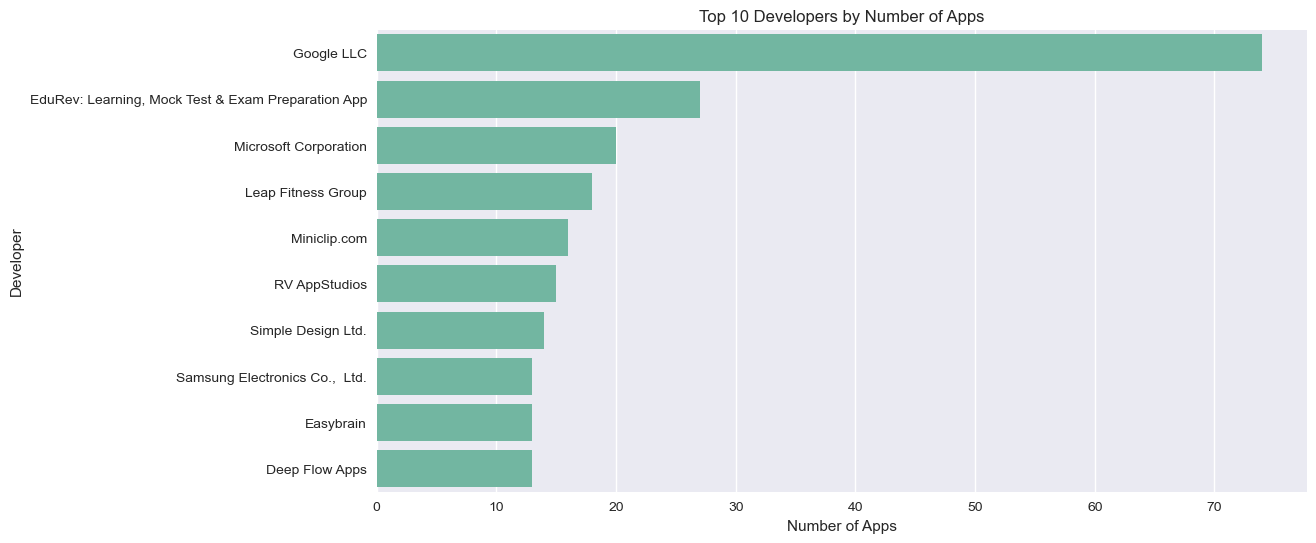

In [37]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_developers.values,
    y=top_developers.index
)

plt.title("Top 10 Developers by Number of Apps")
plt.xlabel("Number of Apps")
plt.ylabel("Developer")

plt.show()

### 📊 Top Developers by App Count

* **Google LLC** leads the dataset with **74 apps**, significantly higher than other developers.
* **EduRev (27 apps)** and **Microsoft Corporation (20 apps)** are the next major contributors.
* Other top developers contribute between **13–18 apps** each.
* The dataset shows a mix of large technology companies and specialized publishers across education, fitness, gaming, and utility categories.
* A few established developers have a stronger presence, but the market remains diverse.


## Question 3:
### Business Question

**Which genres have the highest average ratings?**

A large number of apps in a genre does not necessarily imply higher user satisfaction.

In [38]:
genre_rating = (
    apps.groupby("genre")
    .agg(
        average_rating=("score", "mean"),
        app_count=("app_id", "count")
    )
)

genre_rating = genre_rating[
    genre_rating["app_count"] >= 20
].sort_values(
    by="average_rating",
    ascending=False
)

genre_rating.head(10)

,average_rating,app_count
genre,,
Word,4.369712,73
Puzzle,4.120709,241
Simulation,4.111310,171
Action,4.074528,154
Arcade,4.068972,75
Racing,3.990069,49
Card,3.981521,105
Board,3.867112,123
Video Players & Editors,3.849025,170


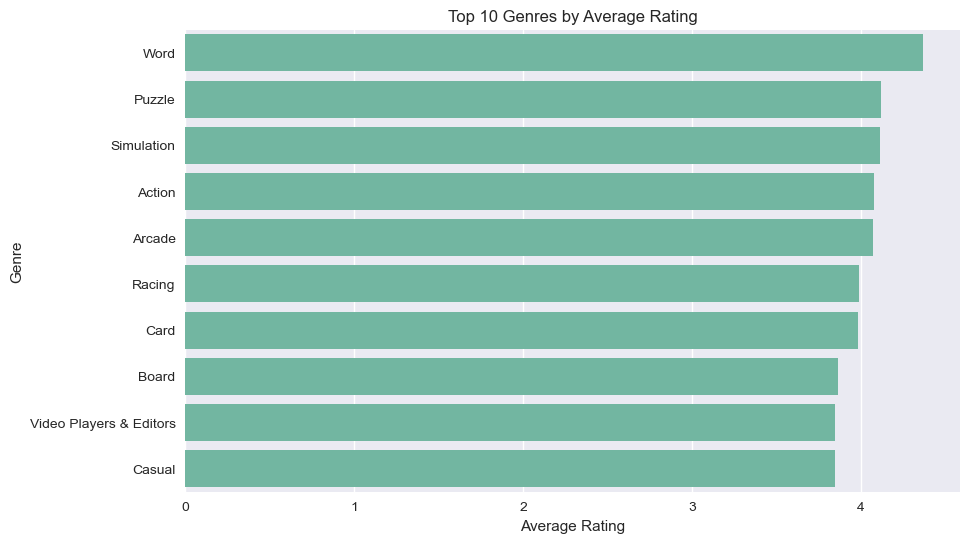

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=genre_rating.head(10),
    x="average_rating",
    y=genre_rating.head(10).index
)

plt.title("Top 10 Genres by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.show()

### 📊 Average Rating by Genre

* **Word apps** have the highest average rating (**4.37**) among the top genres.
* **Puzzle (4.12)** and **Simulation (4.11)** genres also receive strong user ratings.
* **Action (4.07)** and **Arcade (4.07)** maintain high engagement with good ratings.
* Genres like **Video Players & Editors (3.85)** and **Casual (3.84)** have comparatively lower average ratings.
* Overall, game-based categories dominate the highest-rated genres, indicating strong user satisfaction in interactive app categories.


## Question 4:
### Business Question

**Which genres have the highest average estimated installs?**

This helps identify categories with the greatest market reach.

In [40]:
genre_installs = (
    apps.groupby("genre")
    .agg(
        average_installs=("estimated_installs", "mean"),
        app_count=("app_id", "count")
    )
)

genre_installs = genre_installs[
    genre_installs["app_count"] >= 20
].sort_values(
    by="average_installs",
    ascending=False
)

genre_installs.head(10)

,average_installs,app_count
genre,,
Communication,7.772603e+08,137
Auto & Vehicles,3.146353e+08,35
Video Players & Editors,2.129859e+08,170
Social,1.841093e+08,161
Arcade,1.468904e+08,75
Racing,1.378185e+08,49
Tools,1.243223e+08,899
Action,9.761351e+07,154
Travel & Local,8.917811e+07,253


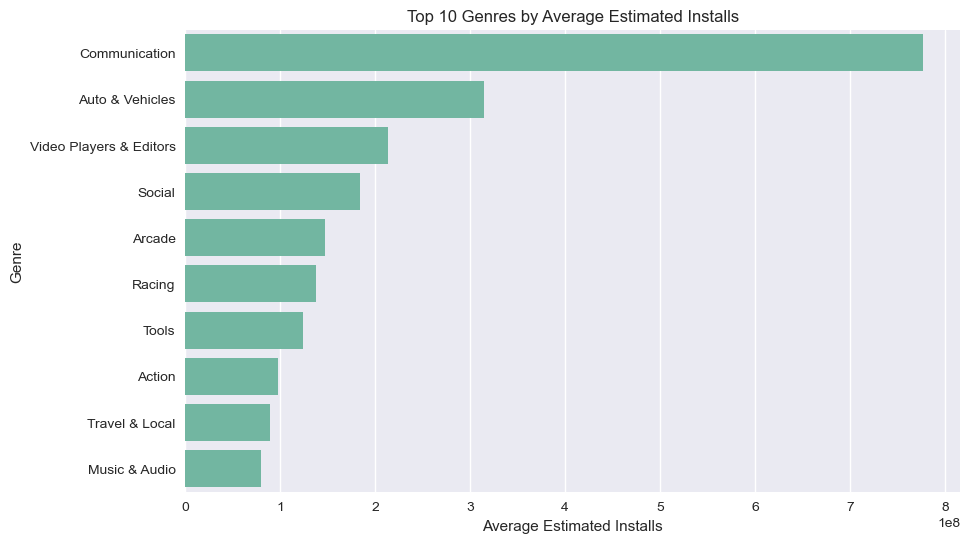

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=genre_installs.head(10),
    x="average_installs",
    y=genre_installs.head(10).index
)

plt.title("Top 10 Genres by Average Estimated Installs")
plt.xlabel("Average Estimated Installs")
plt.ylabel("Genre")

plt.show()

### 📈 Estimated Installs by Genre

* **Communication apps** have the highest estimated installs (**~777 million**), showing strong user demand and widespread adoption.
* **Auto & Vehicles** and **Video Players & Editors** also achieve high install numbers (**300M+ and 200M+ respectively**).
* **Social, Arcade, and Racing** genres show strong popularity with over **100 million estimated installs** each.
* **Tools** have the highest app count (**899 apps**) but comparatively lower average installs per app, suggesting a highly competitive category.
* Overall, communication and utility-focused apps dominate in user reach, while gaming categories maintain strong engagement.


## Question 5:
### Business Question

**Do free and paid applications differ in terms of user adoption and engagement?**

While free applications dominate the marketplace, paid applications may have different performance characteristics. This analysis compares user engagement and popularity metrics between the two monetization models.

In [44]:
free_paid_comparison = (
    apps.groupby("free")
    .agg(
        avg_installs=("estimated_installs", "mean"),
        median_installs=("estimated_installs", "median"),
        avg_rating=("score", "mean"),
        avg_reviews=("reviews", "mean"),
        app_count=("app_id", "count")
    )
)

free_paid_comparison.index = free_paid_comparison.index.map({
    True: "Free",
    False: "Paid"
})

free_paid_comparison

,avg_installs,median_installs,avg_rating,avg_reviews,app_count
free,,,,,
Paid,6.773584e+05,12321.00,2.925562,4153.003817,262
Free,5.552372e+07,599068.75,3.038597,14399.172531,10914


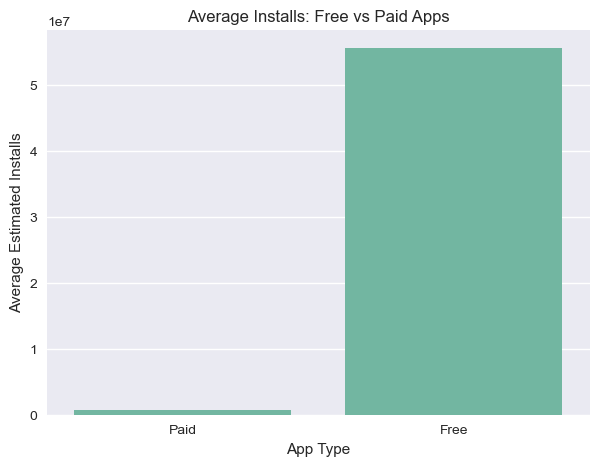

In [45]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=free_paid_comparison.reset_index(),
    x="free",
    y="avg_installs"
)

plt.title("Average Installs: Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Average Estimated Installs")

plt.show()

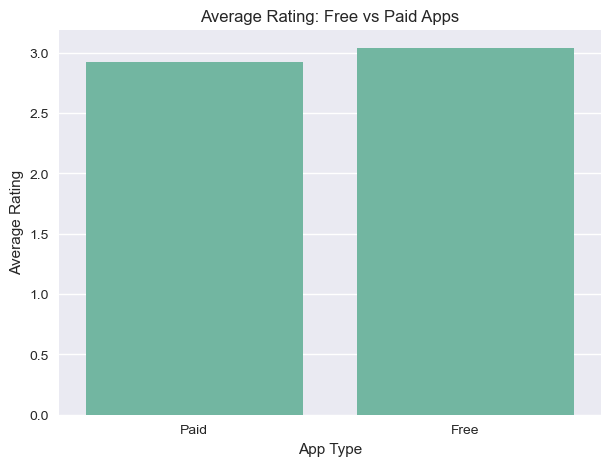

In [46]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=free_paid_comparison.reset_index(),
    x="free",
    y="avg_rating"
)

plt.title("Average Rating: Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Average Rating")

plt.show()

### 📊 Free vs Paid App Comparison

* **Free apps dominate the dataset** with **10,914 apps**, compared to only **262 paid apps**.
* Free apps achieve much higher reach, with an average of **~55.5 million installs** compared to **~677K installs** for paid apps.
* Free apps also have a higher median install count (**~599K**) than paid apps (**~12K**), showing stronger user adoption.
* Ratings are slightly higher for free apps (**3.04**) compared to paid apps (**2.93**).
* Free apps receive significantly more reviews on average (**~14.4K**) than paid apps (**~4.1K**), indicating greater user engagement.
* Overall, the dataset suggests that the free app model has a much larger market reach and user interaction compared to paid apps.


# 6. App Category and Genre Analysis

This section analyzes application distribution and performance across different genres and categories.

The objective is to understand:
- Which categories dominate the Play Store.
- Which categories achieve higher user adoption.
- Which categories receive better ratings.
- Which market segments show stronger opportunities.

A category with a large number of applications does not necessarily indicate better performance, therefore multiple metrics are analyzed.

## Question 1:
### Business Question

**Which app genres contain the highest number of applications?**

Understanding genre distribution helps identify the most competitive areas of the Play Store marketplace.

In [48]:
genre_count = (
    apps["genre"]
    .value_counts()
    .head(15)
)

genre_count

genre
Finance              1215
Education            1104
Productivity          987
Tools                 899
Health & Fitness      601
Business              506
Lifestyle             461
Entertainment         421
Shopping              344
Photography           317
Food & Drink          274
Travel & Local        253
Sports                242
Puzzle                241
Books & Reference     237
Name: count, dtype: int64

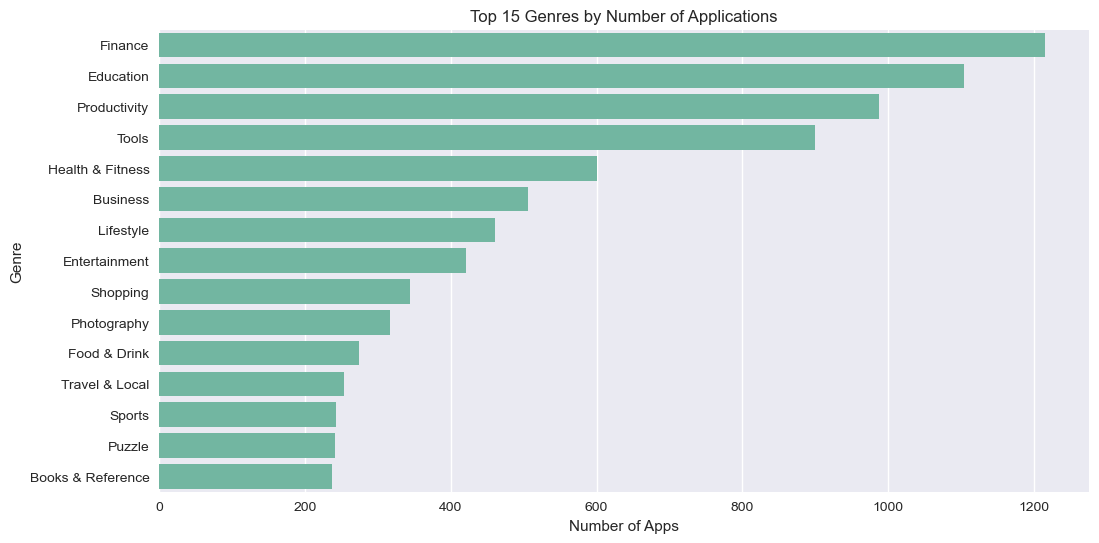

In [49]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=genre_count.values,
    y=genre_count.index
)

plt.title("Top 15 Genres by Number of Applications")
plt.xlabel("Number of Apps")
plt.ylabel("Genre")

plt.show()

### 📊 App Distribution by Genre

* **Finance** is the largest genre in the dataset with **1,215 apps**, followed closely by **Education (1,104 apps)**.
* **Productivity (987 apps)** and **Tools (899 apps)** also have a strong presence, highlighting demand for utility-focused applications.
* **Health & Fitness (601 apps)** and **Business (506 apps)** represent other major categories.
* Entertainment, Shopping, Photography, and Lifestyle categories have moderate representation.
* The dataset is dominated by practical and service-oriented apps, especially in finance, education, productivity, and utility sectors.


## 6.1 Category Competition vs Performance (Important)

### Question : Are competitive categories also the most successful?

In [50]:
genre_summary = (
    apps.groupby("genre")
    .agg(
        apps_count=("app_id","count"),
        avg_installs=("estimated_installs","mean"),
        avg_rating=("score","mean")
    )
    .sort_values(
        "avg_installs",
        ascending=False
    )
)

genre_summary.head(10)

,apps_count,avg_installs,avg_rating
genre,,,
Communication,137,7.772603e+08,3.608910
Auto & Vehicles,35,3.146353e+08,2.704744
Video Players & Editors,170,2.129859e+08,3.849025
Social,161,1.841093e+08,2.964139
Arcade,75,1.468904e+08,4.068972
Racing,49,1.378185e+08,3.990069
Tools,899,1.243223e+08,2.555137
Action,154,9.761351e+07,4.074528
Travel & Local,253,8.917811e+07,3.240796


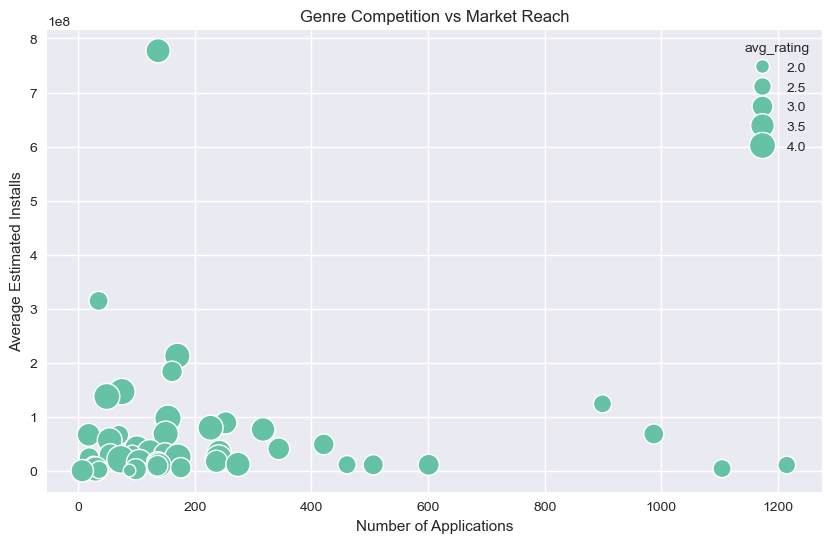

In [51]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=genre_summary,
    x="apps_count",
    y="avg_installs",
    size="avg_rating",
    sizes=(50,400)
)

plt.title(
    "Genre Competition vs Market Reach"
)

plt.xlabel(
    "Number of Applications"
)

plt.ylabel(
    "Average Estimated Installs"
)

plt.show()

### 📈 Genre Performance Analysis (Installs & Ratings)

* **Communication apps** have the highest average installs (**~777 million**), showing exceptional user reach despite having fewer apps (**137**).
* **Auto & Vehicles** and **Video Players & Editors** also achieve high install volumes (**300M+ and 200M+ respectively**).
* **Arcade, Racing, and Action** genres show strong user satisfaction with ratings above **4.0**.
* **Tools** have the largest number of apps (**899**) but lower average ratings (**2.56**), indicating high competition and varied user experience.
* **Social apps** achieve high installs (**~184M**) but have a relatively lower rating (**2.96**).
* Overall, communication and entertainment-focused categories show strong market reach, while gaming categories tend to receive higher user ratings.


# 7: Rating and User Engagement Analysis

This section is important because ratings, reviews, and installs represent different aspects of app success:

Rating → User satisfaction
Reviews → User engagement
Installs → Market adoption

The goal is to understand whether these factors are connected.

-- User ratings and engagement metrics are important indicators of application performance.

This section explores the relationship between:
- User ratings and app popularity.
- Number of reviews and application adoption.
- User engagement patterns across successful applications.

The objective is to understand which factors are associated with higher market performance.

### 7.1 Rating Distribution vs App Success

### Business Question

**Do highly-rated applications achieve more installs?**

A higher rating may indicate better user satisfaction, but it is important to investigate whether this translates into greater market adoption.

In [53]:
# First, create rating groups:
apps["rating_group"] = pd.cut(
    apps["score"],
    bins=[0,3,4,4.5,5],
    labels=[
        "Low (0-3)",
        "Average (3-4)",
        "Good (4-4.5)",
        "Excellent (4.5-5)"
    ]
)

In [54]:
# Compare:
rating_install_analysis = (
    apps.groupby("rating_group", observed=True)
    .agg(
        avg_installs=("estimated_installs","mean"),
        app_count=("app_id","count")
    )
)

rating_install_analysis

,avg_installs,app_count
rating_group,,
Low (0-3),1.200903e+07,263
Average (3-4),8.111060e+07,1419
Good (4-4.5),1.002871e+08,2929
Excellent (4.5-5),5.866504e+07,3299


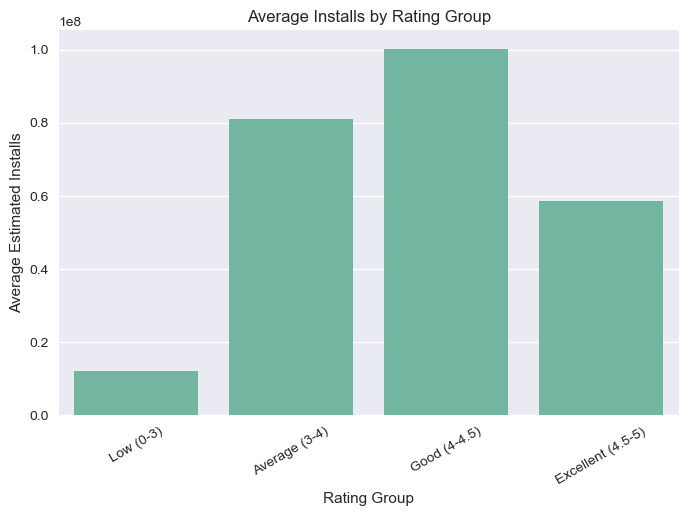

In [55]:
# Visualization:
plt.figure(figsize=(8,5))

sns.barplot(
    data=rating_install_analysis.reset_index(),
    x="rating_group",
    y="avg_installs"
)

plt.title(
    "Average Installs by Rating Group"
)

plt.xlabel("Rating Group")
plt.ylabel("Average Estimated Installs")

plt.xticks(rotation=30)

plt.show()

### Insight

Rating alone does not always determine app success.

While highly-rated applications may indicate better user satisfaction, install numbers are also influenced by factors such as brand recognition, marketing, category demand, and app visibility.

### 7.2 Reviews vs Installs :

### Business Question

**Do applications with more reviews achieve higher installs?**

Reviews represent user engagement and can indicate how widely an application is being used.

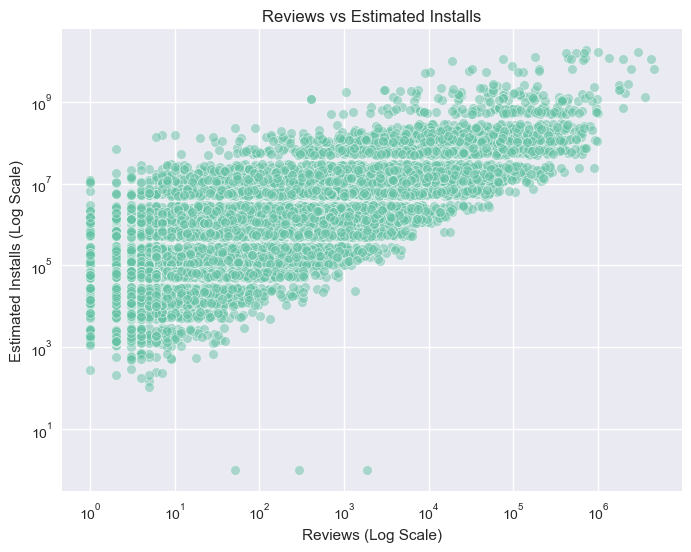

In [56]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=apps,
    x="reviews",
    y="estimated_installs",
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Reviews vs Estimated Installs"
)

plt.xlabel(
    "Reviews (Log Scale)"
)

plt.ylabel(
    "Estimated Installs (Log Scale)"
)

plt.show()

In [57]:
# Calculate Correlation :
apps[
    ["reviews","estimated_installs"]
].corr()

,reviews,estimated_installs
reviews,1.000000,0.472181
estimated_installs,0.472181,1.000000


### 📊 Correlation Between Reviews and Installs

* The correlation between **reviews** and **estimated installs** is **0.47**, indicating a **moderate positive relationship**.
* Apps with more installs generally tend to receive more reviews, but the relationship is not very strong.
* The moderate correlation suggests that factors other than install count—such as user engagement, app category, or review behavior—also influence the number of reviews.
* Overall, install count is associated with review count, but it is **not the sole predictor** of user reviews.


# 8. Country-Level Market Analysis

### Business Questions

1. Which countries have the highest average app ratings?

2. Which countries generate the highest average installs?


### Analysis 1: Average Rating by Country

In [58]:
country_rating = (
    country.groupby("country")
    .agg(
        avg_rating=("score", "mean"),
        app_count=("app_id", "count")
    )
)

country_rating = country_rating[country_rating["app_count"] >= 100]
country_rating = country_rating.sort_values("avg_rating", ascending=False)

country_rating.head(10)

,avg_rating,app_count
country,,
in,3.215182,11046
us,3.036025,11171
br,2.853718,11147
id,2.793407,11143
mx,2.746336,11143
ph,2.736338,11126
gb,2.702246,11141
de,2.619567,11133
kr,2.585030,11129


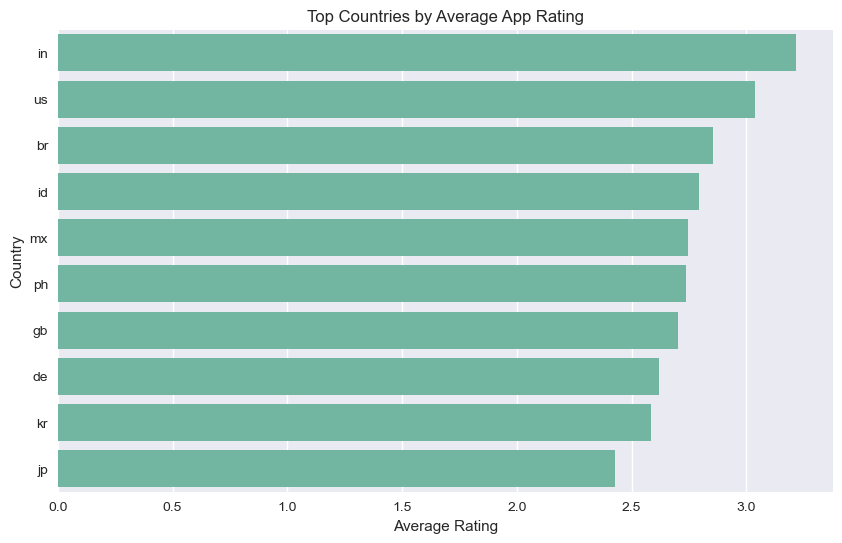

In [59]:
# Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    data=country_rating.head(10).reset_index(),
    x="avg_rating",
    y="country"
)

plt.title("Top Countries by Average App Rating")
plt.xlabel("Average Rating")
plt.ylabel("Country")

plt.show()

### 📊 Average App Ratings by Country

* **India** has the highest average app rating (**3.22**) among the countries analyzed.
* The **United States** ranks second with an average rating of **3.04**.
* **Brazil, Indonesia, and Mexico** follow with average ratings between **2.75–2.85**.
* **Japan** has the lowest average rating (**2.43**) among the top countries listed.
* The app counts are nearly identical across countries, indicating that the differences are primarily in average ratings rather than dataset size.


### Analysis 2: Average Estimated Installs by Country

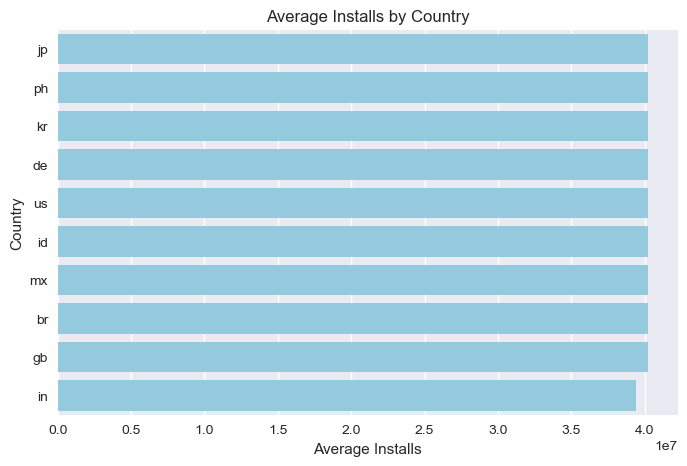

In [64]:
top10 = country_installs.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top10["avg_installs"], y=top10.index, color="skyblue")

plt.title("Average Installs by Country")
plt.xlabel("Average Installs")
plt.ylabel("Country")

plt.show()

### 📊 Average Installs by Country

* **Japan** has the highest average installs (**~40.25 million**) among the countries analyzed.
* **Philippines, South Korea, Germany, and the United States** closely follow, with average installs of approximately **40.2 million**.
* **India** records the lowest average installs (**~39.44 million**) among the listed countries.
* The differences in average installs across countries are relatively small, indicating a fairly consistent level of app adoption in the dataset.
* Since the app counts are nearly identical across countries, the comparison is not influenced by differences in sample size.


#  9. Discovery Signal Analysis

### Business Question

How are successful apps discovered?

### Analysis 1: Discovery Sources

In [66]:
discovery["source"].value_counts()

source
search        53194
chart_page    18726
archive        3892
Name: count, dtype: int64

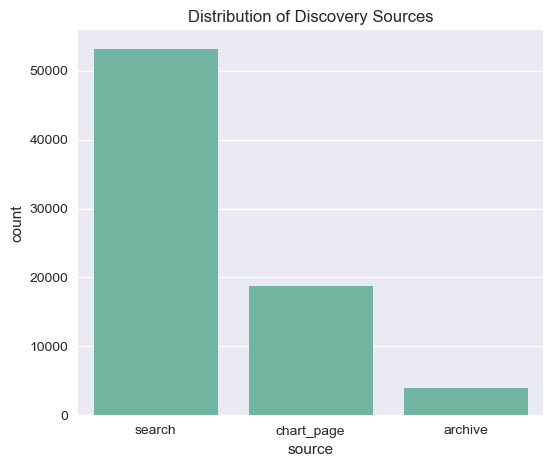

In [67]:
# Visualization
plt.figure(figsize=(6,5))

sns.countplot(
    data=discovery,
    x="source",
    order=discovery["source"].value_counts().index
)

plt.title("Distribution of Discovery Sources")

plt.show()

### 📊 App Discovery Sources

* **Search** is the primary discovery channel, accounting for **53,194 apps**, making it the most important source of app visibility.
* **Chart Page** is the second-largest source with **18,726 apps**, indicating that featured rankings also drive app discovery.
* **Archive** contributes the fewest apps (**3,892**), suggesting it plays a relatively minor role.
* Overall, users are far more likely to discover apps through **search** than through charts or archived listings.


### Analysis 2: Top Search Keywords

In [68]:
discovery["keyword"].value_counts().head(15)

keyword
Not Available            22618
smart utility              279
astrology app hindi        244
hinglish english           237
study app hindi            220
health tips hindi          200
kundli                     200
ssc quiz                   200
invoice scanner hindi      195
photo editor hindi         191
ludo                       184
phi-3                      183
gemma                      182
short drama app hindi      182
bengali app                182
Name: count, dtype: int64

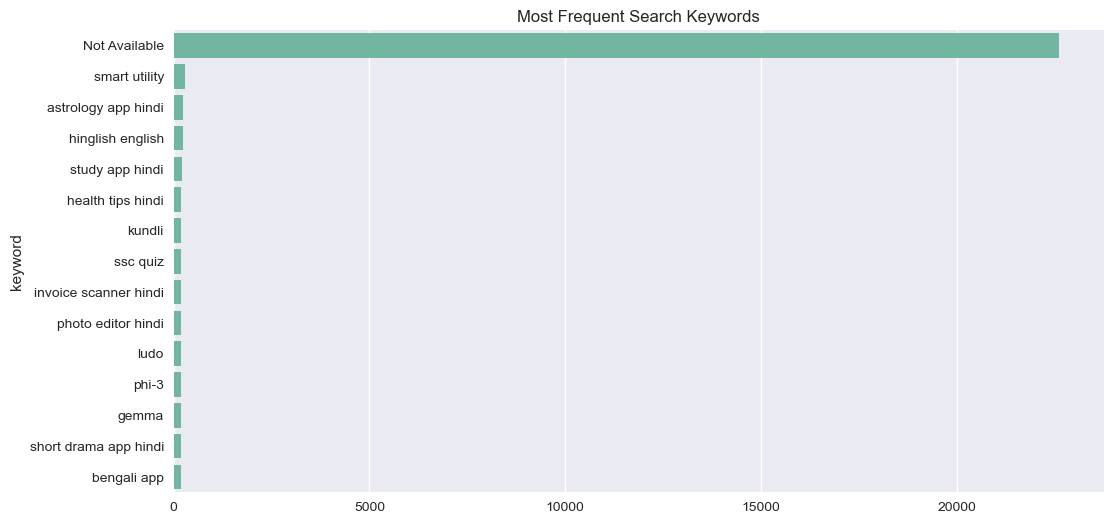

In [69]:
# Visualization :
plt.figure(figsize=(12,6))

sns.barplot(
    x=discovery["keyword"].value_counts().head(15).values,
    y=discovery["keyword"].value_counts().head(15).index
)

plt.title("Most Frequent Search Keywords")

plt.show()

### 🔍 App Discovery Keywords Analysis

* A large number of apps (**22,618**) have **no available keyword**, limiting visibility analysis.
* Among available keywords, **"smart utility"** is the most common keyword with **279 apps**.
* Regional and language-based keywords such as **"astrology app hindi", "hinglish english", and "study app hindi"** appear frequently, showing demand for localized apps.
* Education-related keywords like **"ssc quiz"** indicate strong interest in exam preparation apps.
* Popular utility and entertainment keywords such as **"invoice scanner", "photo editor", and "ludo"** highlight common app discovery trends.
* Overall, keyword usage suggests that **localization, utility, and education-focused terms help improve app discoverability**.


# 10. Correlation Analysis

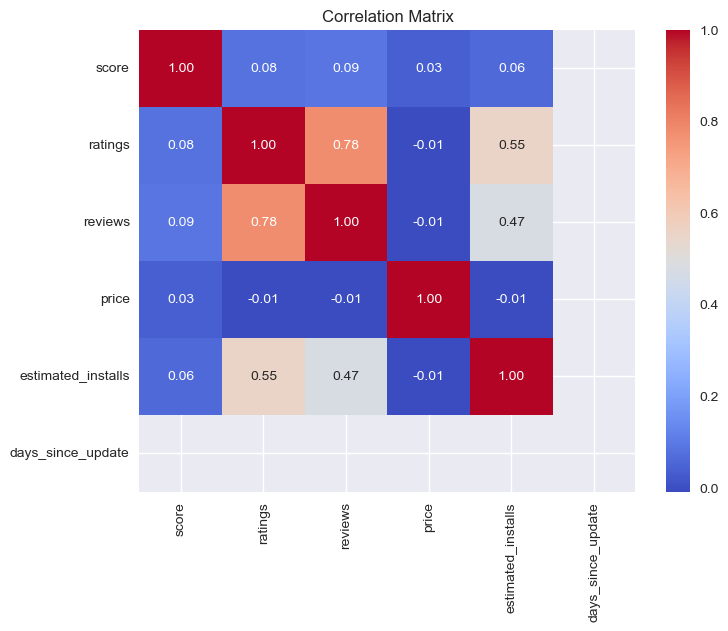

In [71]:
numeric_cols = [
    "score",
    "ratings",
    "reviews",
    "price",
    "estimated_installs",
    "days_since_update"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    apps[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### 📊 Key Insights: Correlation Matrix

The heatmap illustrates the Pearson correlation coefficients among the dataset's numerical metrics, revealing how different variables move in relation to one another:

* **Strong Interdependence Between Ratings and Reviews:** 
  There is a strong positive correlation (**0.78**) between `ratings` and `reviews`. This indicates that as an app receives more reviews, its total rating count increases proportionally, which aligns with standard user engagement behavior.
* **Engagement Drives Installs:** 
  The feature `estimated_installs` shows moderate-to-strong positive correlations with both `ratings` (**0.55**) and `reviews` (**0.47**). This confirms that high user interaction metrics serve as strong trailing indicators (or drivers) of an app's download volume.
* **App Scores and Price operate Independently:** 
  The user `score` (average rating out of 5) has near-zero correlation with all other features (ranging from 0.03 to 0.09). Similarly, `price` shows virtually zero relationship with popularity, engagement, or score (-0.01). This tells us that an app's quality score and pricing strategy are independent of its scale.
* **The "Days Since Update" Missing Data Artifact:** 
  The `days_since_update` row and column appear completely blank or dropped from the matrix calculation. This is a direct consequence of the upstream data quality issue identified earlier—because the column contains zero variance (all values are identical due to the 1970 timestamp error), a correlation coefficient cannot mathematically be computed for it.

# 11. Outlier Analysis

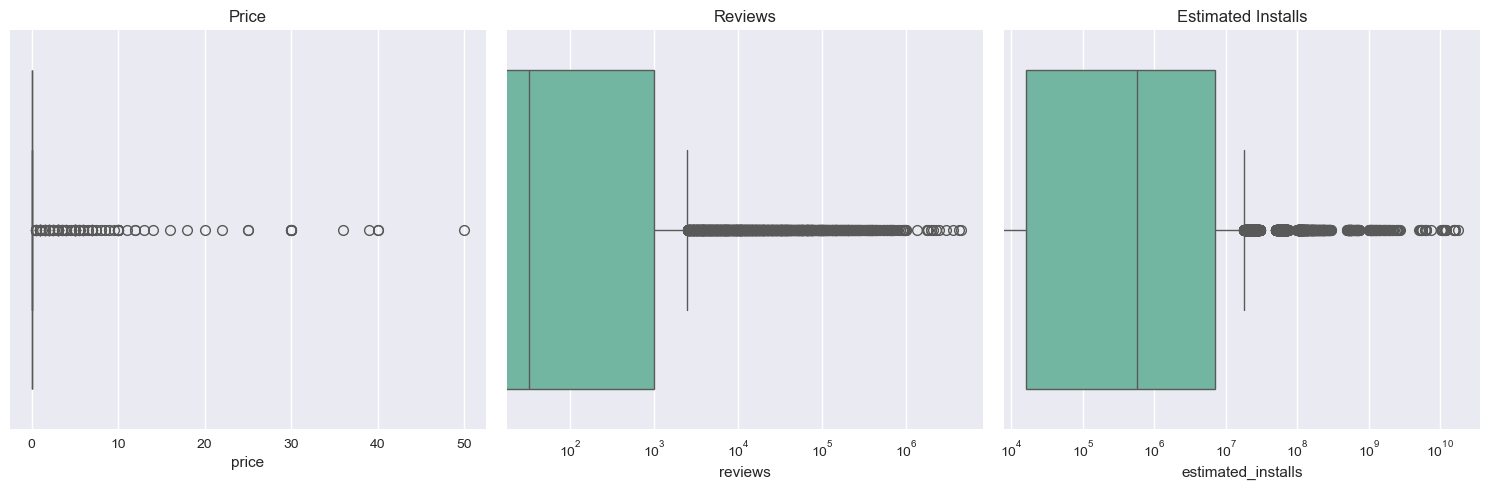

In [72]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(x=apps["price"], ax=ax[0])
ax[0].set_title("Price")

sns.boxplot(x=apps["reviews"], ax=ax[1])
ax[1].set_xscale("log")
ax[1].set_title("Reviews")

sns.boxplot(x=apps["estimated_installs"], ax=ax[2])
ax[2].set_xscale("log")
ax[2].set_title("Estimated Installs")

plt.tight_layout()
plt.show()

### 📊 Key Insights: Price, Reviews, and Estimated Installs Outliers

The three box plots visualize the distribution density and highlight statistical outliers across key numeric features:

* **Price Outliers (Linear Scale):** 
  Because the vast majority of apps are free, the main box is completely compressed against `0`. The individual circles extending out toward `50` represent paid apps that function as statistical outliers relative to the entire dataset.
* **Reviews Outliers (Log Scale):** 
  The reviews box plot uses a log scale, showing a dense concentration of apps under $10^3$ (1,000) reviews. The massive horizontal trail of black points stretching out past $10^6$ highlights the small cluster of hyper-popular apps that dominate user engagement.
* **Estimated Installs Outliers (Log Scale):** 
  Similar to reviews, the bulk of the install distribution sits safely between $10^4$ and $10^7$ downloads. Apps breaking past $10^7$ up to $10^{10}$ are plotted as outliers, indicating the select few apps that achieve global scale.
* **Data Preparation Takeaway:** 
  The extreme presence of extreme outliers across all three metrics confirms that standard linear normalization techniques (like MinMaxScaler) will fail. Outlier-robust methods like log transformation or using a `RobustScaler` are highly recommended before feeding these fields into an ML model.

# 12. Key Findings and Business Insights

The exploratory data analysis revealed several important patterns about the Google Play Store ecosystem.

## 1. App Market Structure

- The dataset contains **11,176 applications** across multiple genres and categories, representing a diverse application marketplace.
- The marketplace is highly concentrated around free applications, indicating that free-to-use and freemium strategies dominate the mobile app ecosystem.
- Developer activity is unevenly distributed, where a smaller group of developers publish multiple applications while many developers contribute only a limited number of apps.

## 2. App Popularity is Highly Uneven

- Estimated installs show a highly right-skewed distribution, meaning a small number of applications achieve extremely large user adoption while the majority of apps have comparatively lower installs.
- Because of this imbalance, average values alone can be misleading, and median values and log transformations provide better representation of app performance.
- This indicates that success in the Play Store follows a "winner takes most" pattern, where a small group of applications capture a significant share of user attention.

## 3. Ratings Do Not Fully Explain App Success

- Analysis between ratings and installs showed that higher ratings do not automatically guarantee higher adoption.
- Many highly-rated applications have limited installs, suggesting that visibility, marketing, category demand, and existing user base also play important roles.
- Ratings should therefore be interpreted as a measure of user satisfaction rather than a direct measure of popularity.

## 4. Reviews are a Stronger Indicator of User Adoption

- Reviews showed a stronger relationship with installs compared to ratings.
- Applications with larger install bases generally receive more reviews because a larger user population creates more opportunities for feedback.
- However, this relationship represents association rather than direct causation because popularity itself increases both installs and reviews.

## 5. Category Performance and Market Opportunities

- The number of applications within a genre does not directly indicate success.
- Some genres with fewer applications achieved higher average installs, showing that competition level and market demand are not always aligned.
- Category analysis suggests that opportunities may exist in less crowded segments with strong user adoption.

## 6. Monetization Insights

- Free applications represent the majority of the marketplace, while paid applications form a relatively small segment.
- Price distribution is extremely skewed (skewness ≈ 20.25), indicating that most applications are free or low-priced while a small number of premium applications have significantly higher prices.
- This suggests that successful monetization in mobile applications is primarily driven through free distribution models, subscriptions, advertisements, or in-app purchases rather than upfront pricing.

## 7. Geographic and Discovery Insights

- Country-level analysis showed variations in app performance across different markets, indicating that user demand is not evenly distributed globally.
- The discovery dataset provided additional visibility into how applications appear through different channels such as search results and chart rankings.
- Discovery signals can help explain why some applications achieve higher visibility and adoption compared to others.

## 8. Data Quality and Feature Preparation Insights

- Several columns contained significant missing information, but missing values were handled based on business meaning rather than simply removing incomplete records.
- Features such as estimated installs, update recency, and missing-value indicators were created to preserve information and improve future analysis.
- Highly skewed variables such as installs, reviews, and price require transformation or careful interpretation during modeling.

# 13. Conclusion

The exploratory data analysis provided a detailed understanding of the factors influencing application performance in the Google Play Store ecosystem.

The analysis indicates that app success is not determined by a single metric. Instead, successful applications generally combine strong user adoption, high engagement, category demand, developer capability, and market visibility.

The major findings are:

1. The Play Store follows a highly concentrated market structure where a small number of applications dominate installs and engagement.

2. User engagement metrics, especially review volume, provide stronger signals of adoption than ratings alone.

3. Category selection plays an important role, as some genres achieve stronger market performance despite having fewer competing applications.

4. Free applications dominate the ecosystem, while paid applications represent a smaller but distinct market segment.

5. Geographic distribution and discovery channels provide additional context for understanding app visibility and growth opportunities.

These findings will be used in the next phase of the project to create meaningful analytical features, perform SQL-based business analysis, and develop Power BI dashboards focused on app performance, user engagement, monetization, and market trends.